In [26]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts.analysis_utils import get_density2d, get_density1d, \
    make_levels, add_colorbar, add_crosshair

In [27]:
data = np.loadtxt('all_real_output.txt')
#data = data[np.isin(data[:, 2], [20251113.0, 20251116.0, 20251119.0])]
print(f'Number of pointings: {len(np.unique(data[:, 0:2], axis=0))}')
print(f'Number of days: {len(np.unique(data[:, 2]))}')
print(f'Total fraction of recovered injections: {(100*len(data[data[:, -1] > 0.])/len(data)):.2f}%')
print(f'Number of injections: {len(data)}')
RA = data[:, 0]
Dec = data[:, 1]
f = data[:, 4]
DM = data[:, 5]
S = data[:, 6]
TPA_idx = data[:, 3].astype('int')
fwhm_array = np.load('../profiles/TPA_fwhm.npy')
fwhm = fwhm_array[TPA_idx]
data[:, 7] = fwhm

Number of pointings: 9909
Number of days: 6
Total fraction of recovered injections: 26.27%
Number of injections: 149992


In [28]:
RA_dev = 10
Dec_dev = 10
f_dev = 50
DM_dev = 100
S_dev = 5
FWHM_dev = 5

In [29]:
f_bins1d = np.logspace(np.log10(min(f)), np.log10(max(f)), 101)
f_injected, f_retrieved = get_density1d(data, 4, f_bins1d)
f_inj_smooth = gaussian_filter(f_injected, 5)
f_inj_p = f_inj_smooth / np.sum(f_inj_smooth)
f_ret_smooth = gaussian_filter(f_retrieved, 5)
f_ret_p = f_ret_smooth / f_inj_smooth

DM_bins1d = np.linspace(0, 700, 100)
DM_injected, DM_retrieved = get_density1d(data, 5, DM_bins1d)
DM_inj_smooth = gaussian_filter(DM_injected, 30)
DM_inj_p = DM_inj_smooth / np.sum(DM_inj_smooth)
DM_ret_smooth = gaussian_filter(DM_retrieved, 30)
DM_ret_p = DM_ret_smooth / DM_inj_smooth
DM_ret_p[np.isnan(DM_ret_p)] = 0

S_bins = np.logspace(np.log10(min(S)), np.log10(max(S)), 51)
S_injected, S_retrieved = get_density1d(data, 6, S_bins)
S_inj_smooth = gaussian_filter(S_injected, S_dev)
S_inj_p = S_inj_smooth / np.sum(S_inj_smooth)
S_ret_smooth = gaussian_filter(S_retrieved, S_dev)
S_ret_p = S_ret_smooth / S_inj_smooth

fwhm_bins1d = np.logspace(np.log10(min(fwhm)), -0.95, 101)
fwhm_injected, fwhm_retrieved = get_density1d(data, 7, fwhm_bins1d)
fwhm_inj_smooth = gaussian_filter(fwhm_injected, 15)
fwhm_inj_p = fwhm_inj_smooth / np.sum(fwhm_inj_smooth)
fwhm_ret_smooth = gaussian_filter(fwhm_retrieved, 15)
fwhm_ret_p = fwhm_ret_smooth / fwhm_inj_smooth

RA_bins1d = np.linspace(0, 360, 100)
ra_injected, ra_retrieved = get_density1d(data, 0, RA_bins1d)
ra_inj_smooth = gaussian_filter(ra_injected, 10)
ra_inj_p = ra_inj_smooth / np.sum(ra_inj_smooth)
ra_ret_smooth = gaussian_filter(ra_retrieved, 10)
ra_ret_p = ra_ret_smooth / ra_inj_smooth

Dec_bins1d = np.linspace(min(Dec), max(Dec), 70)
dec_injected, dec_retrieved = get_density1d(data, 1, Dec_bins1d)
dec_inj_smooth = gaussian_filter(dec_injected, 20)
dec_inj_p = dec_inj_smooth / np.sum(dec_inj_smooth)
dec_ret_smooth = gaussian_filter(dec_retrieved, 20)
dec_ret_p = dec_ret_smooth / dec_inj_smooth

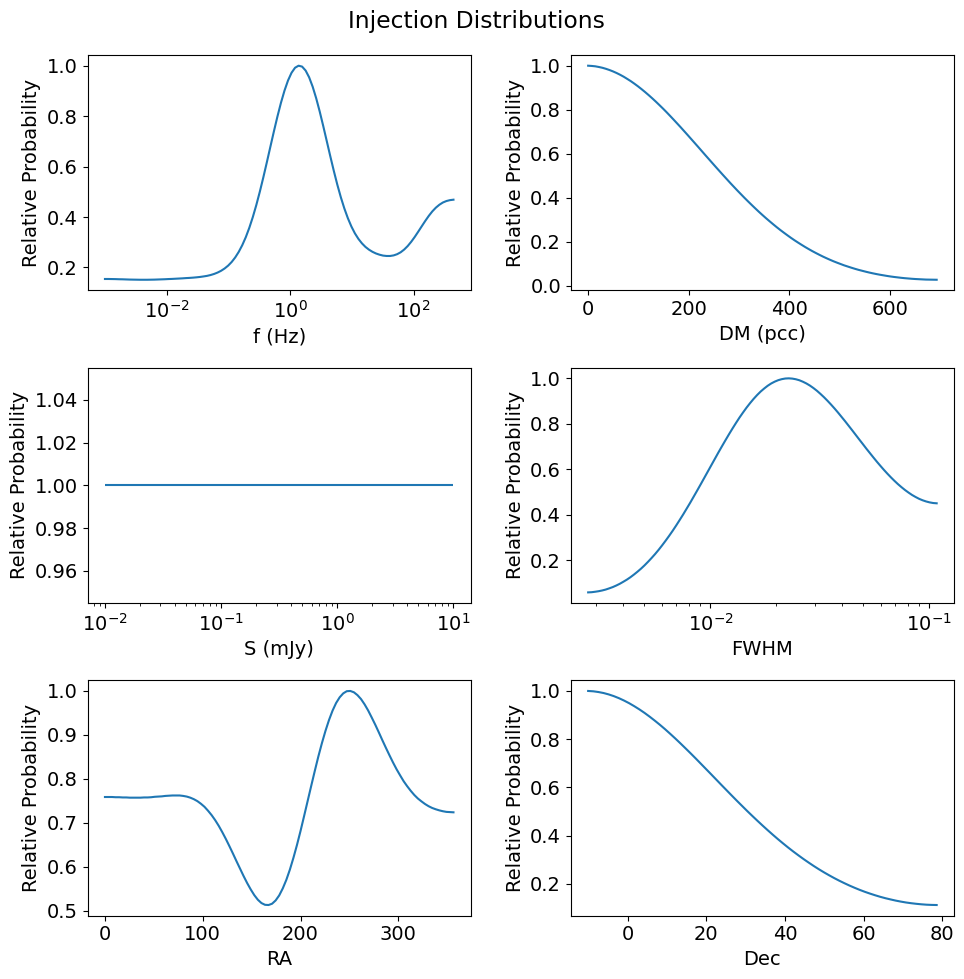

In [30]:
fig, ax = plt.subplots(3, 2, figsize = (10, 10))
ax = ax.flatten()

ax[0].plot(f_bins1d[:-1], f_inj_p/np.max(f_inj_p))
ax[0].set_xscale('log')
ax[0].set_xlabel('f (Hz)')
ax[0].set_ylabel('Relative Probability')

ax[1].plot(DM_bins1d[:-1], DM_inj_p/np.max(DM_inj_p))
ax[1].set_xlabel('DM (pcc)')
ax[1].set_ylabel('Relative Probability')

ax[2].hlines(1, S_bins[0], S_bins[-1])
ax[2].set_xscale('log')
ax[2].set_xlabel('S (mJy)')
ax[2].set_ylabel('Relative Probability')

ax[3].plot(fwhm_bins1d[:-1], fwhm_inj_p/np.max(fwhm_inj_p))
ax[3].set_xscale('log')
ax[3].set_xlabel('FWHM')
ax[3].set_ylabel('Relative Probability')

ax[4].plot(RA_bins1d[:-1], ra_inj_p/np.max(ra_inj_p))
ax[4].set_xlabel('RA')
ax[4].set_ylabel('Relative Probability')

ax[5].plot(Dec_bins1d[:-1], dec_inj_p/np.max(dec_inj_p))
ax[5].set_xlabel('Dec')
ax[5].set_ylabel('Relative Probability')

fig.suptitle('Injection Distributions')
plt.tight_layout()

In [31]:
f_bins1d = np.logspace(np.log10(min(f)), np.log10(max(f)), 101)
f_injected, f_retrieved = get_density1d(data, 4, f_bins1d)
f_inj_smooth = gaussian_filter(f_injected, 5)
f_inj_p = f_inj_smooth / np.sum(f_inj_smooth)
f_ret_smooth = gaussian_filter(f_retrieved, 5)
f_ret_p = f_ret_smooth / f_inj_smooth

DM_bins1d = np.linspace(0, 700, 100)
DM_injected, DM_retrieved = get_density1d(data, 5, DM_bins1d)
DM_inj_smooth = gaussian_filter(DM_injected, 30)
DM_inj_p = DM_inj_smooth / np.sum(DM_inj_smooth)
DM_ret_smooth = gaussian_filter(DM_retrieved, 30)
DM_ret_p = DM_ret_smooth / DM_inj_smooth
DM_ret_p[np.isnan(DM_ret_p)] = 0

S_injected, S_retrieved = get_density1d(data, 6, S_bins)
S_inj_smooth = gaussian_filter(S_injected, S_dev)
S_inj_p = S_inj_smooth / np.sum(S_inj_smooth)
S_ret_smooth = gaussian_filter(S_retrieved, S_dev)
S_ret_p = S_ret_smooth / S_inj_smooth

fwhm_bins1d = np.logspace(np.log10(min(fwhm)), -0.95, 51)
fwhm_injected, fwhm_retrieved = get_density1d(data, 7, fwhm_bins1d)
fwhm_inj_smooth = gaussian_filter(fwhm_injected, 15)
fwhm_inj_p = fwhm_inj_smooth / np.sum(fwhm_inj_smooth)
fwhm_ret_smooth = gaussian_filter(fwhm_retrieved, 15)
fwhm_ret_p = fwhm_ret_smooth / fwhm_inj_smooth

RA_bins1d = np.linspace(0, 360, 100)
ra_injected, ra_retrieved = get_density1d(data, 0, RA_bins1d)
ra_inj_smooth = gaussian_filter(ra_injected, 10)
ra_inj_p = ra_inj_smooth / np.sum(ra_inj_smooth)
ra_ret_smooth = gaussian_filter(ra_retrieved, 10)
ra_ret_p = ra_ret_smooth / ra_inj_smooth

Dec_bins1d = np.linspace(min(Dec), max(Dec), 70)
dec_injected, dec_retrieved = get_density1d(data, 1, Dec_bins1d)
dec_inj_smooth = gaussian_filter(dec_injected, 20)
dec_inj_p = dec_inj_smooth / np.sum(dec_inj_smooth)
dec_ret_smooth = gaussian_filter(dec_retrieved, 20)
dec_ret_p = dec_ret_smooth / dec_inj_smooth

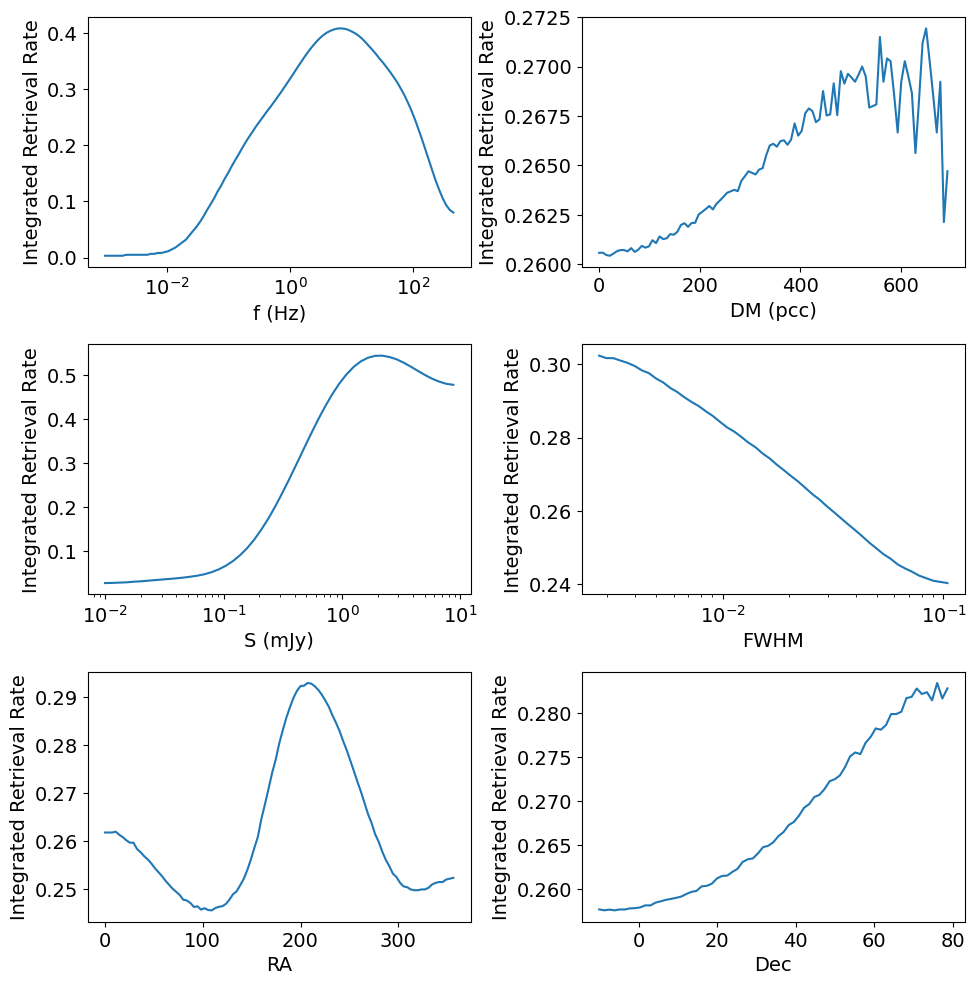

In [32]:
fig, ax = plt.subplots(3, 2, figsize = (10, 10))
ax = ax.flatten()

ax[0].plot(f_bins1d[:-1], f_ret_p)
ax[0].set_xscale('log')
ax[0].set_xlabel('f (Hz)')
ax[0].set_ylabel('Integrated Retrieval Rate')

ax[1].plot(DM_bins1d[:-1], DM_ret_p)
ax[1].set_xlabel('DM (pcc)')
ax[1].set_ylabel('Integrated Retrieval Rate')

ax[2].plot(S_bins[:-1], S_ret_p)
ax[2].set_xscale('log')
ax[2].set_xlabel('S (mJy)')
ax[2].set_ylabel('Integrated Retrieval Rate')

ax[3].plot(fwhm_bins1d[:-1], fwhm_ret_p)
ax[3].set_xscale('log')
ax[3].set_xlabel('FWHM')
ax[3].set_ylabel('Integrated Retrieval Rate')

ax[4].plot(RA_bins1d[:-1], ra_ret_p)
ax[4].set_xlabel('RA')
ax[4].set_ylabel('Integrated Retrieval Rate')

ax[5].plot(Dec_bins1d[:-1], dec_ret_p)
ax[5].set_xlabel('Dec')
ax[5].set_ylabel('Integrated Retrieval Rate')

plt.tight_layout()